In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
DATA_DIR = "D:/GADA Labs/eurosat-land-classification/data/EuroSAT"

train_df = pd.read_csv(f"{DATA_DIR}/train.csv").drop(columns=["Unnamed: 0"])
val_df   = pd.read_csv(f"{DATA_DIR}/validation.csv").drop(columns=["Unnamed: 0"])
test_df  = pd.read_csv(f"{DATA_DIR}/test.csv").drop(columns=["Unnamed: 0"])

with open(f"{DATA_DIR}/label_map.json") as f:
    label_map = json.load(f)

print(train_df.shape, val_df.shape, test_df.shape)
print(label_map)

(18900, 3) (5400, 3) (2700, 3)
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


The dataset has already been split into train, validation and test sets. It follows standard ratio: train - **70%**, validation - **20%**, test - **10%**.

Next, class balance across all splits will be checked.

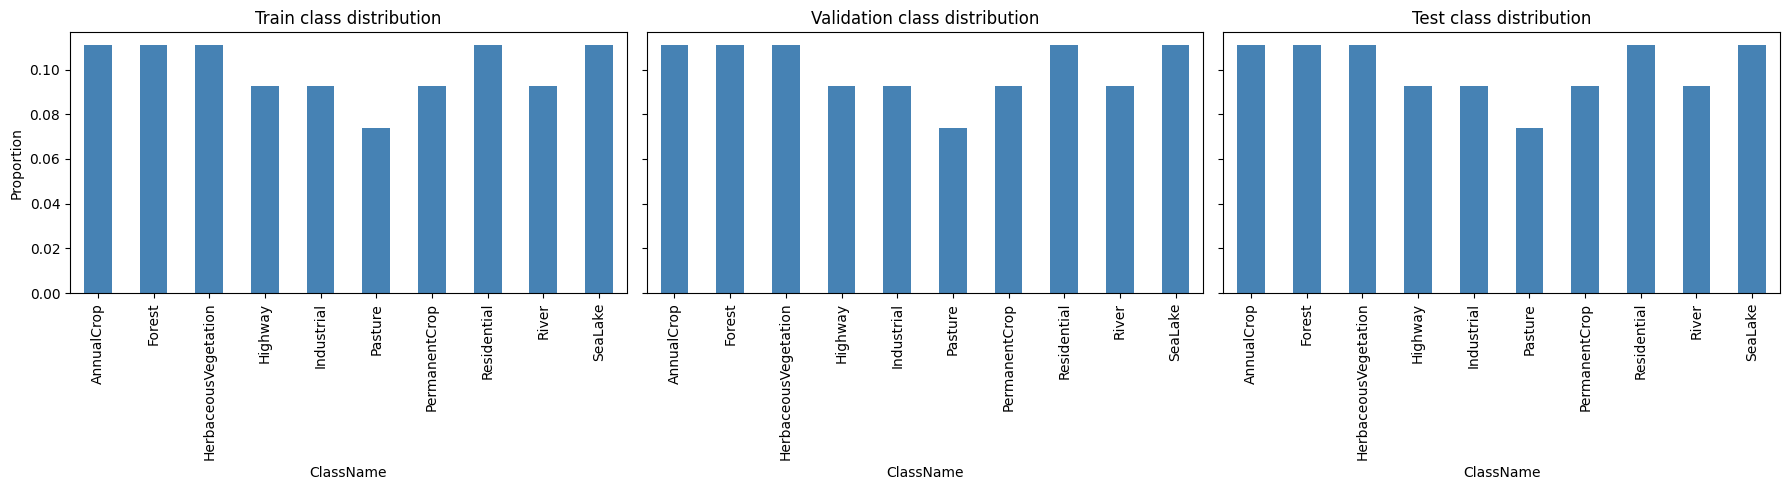

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, df, name in zip(axes, [train_df, val_df, test_df], ["Train", "Validation", "Test"]):
    df['ClassName'].value_counts(normalize=True).sort_index().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f"{name} class distribution")
    ax.set_ylabel("Proportion")
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

The class balance is preserved across all splits. Classes' shares range from **7.4%** to **11.1%**, which is close to perfect balance. SMOTE or other class imbalance solution techniques are not needed. 

Samples of images and their properties will be reviewed

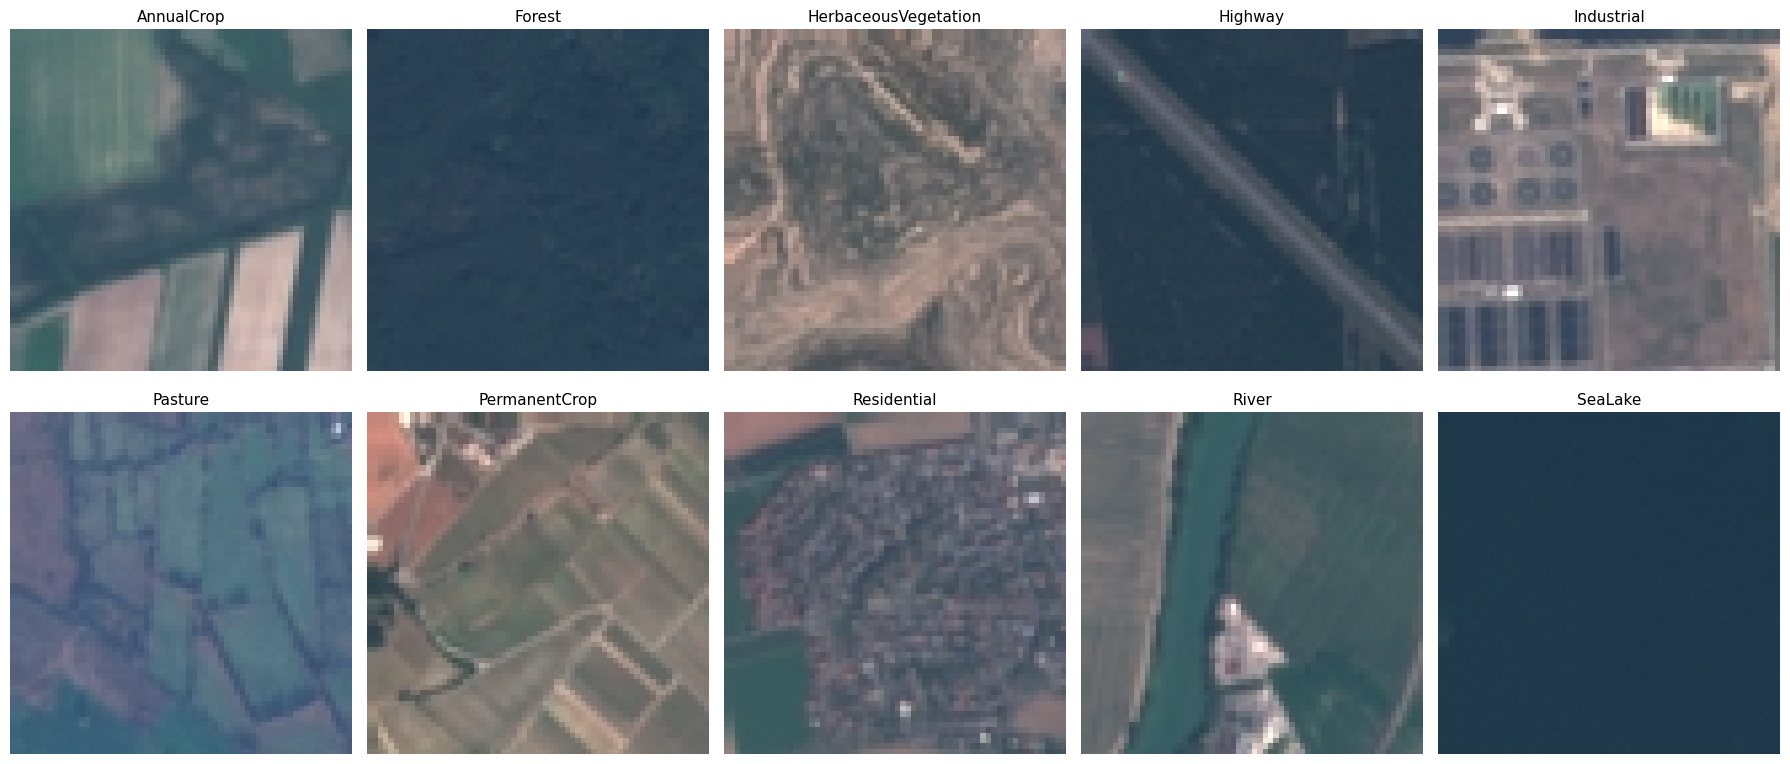

In [7]:
sample_per_class = train_df.groupby('ClassName').sample(n=1, random_state=42)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_per_class.iterrows()):
    img_path = f"{DATA_DIR}/{row['Filename']}"
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(row['ClassName'], fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
sample_check = train_df.groupby('ClassName').sample(n=1, random_state=42)

for _, row in sample_check.iterrows():
    img_path = f"{DATA_DIR}/{row['Filename']}"
    img = Image.open(img_path)
    print(f"{row['ClassName']:25s} size={img.size} mode={img.mode}")

AnnualCrop                size=(64, 64) mode=RGB
Forest                    size=(64, 64) mode=RGB
HerbaceousVegetation      size=(64, 64) mode=RGB
Highway                   size=(64, 64) mode=RGB
Industrial                size=(64, 64) mode=RGB
Pasture                   size=(64, 64) mode=RGB
PermanentCrop             size=(64, 64) mode=RGB
Residential               size=(64, 64) mode=RGB
River                     size=(64, 64) mode=RGB
SeaLake                   size=(64, 64) mode=RGB


The images retrieved from the dataset look normal, nothing unusual was identified. The labels also appear to fit. All images share the same properties.

In [9]:
class EuroSATDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = f"{self.data_dir}/{row['Filename']}"
        image = Image.open(img_path).convert("RGB")
        label = row['Label']

        if self.transform:
            image = self.transform(image)

        return image, label

In order to make training more effective the dataset should be normalized. First, mean and std of each image channel will be calculared.

In [10]:
basic_transform = transforms.Compose([
    transforms.ToTensor()
])

stats_dataset = EuroSATDataset(train_df, DATA_DIR, transform=basic_transform)
stats_loader = DataLoader(stats_dataset, batch_size=256, shuffle=False, num_workers=0)

def compute_mean_std(loader):
    pixel_sum = torch.zeros(3)
    pixel_sq_sum = torch.zeros(3)
    n_pixels = 0

    for images, _ in tqdm(loader):
        images = images
        b, c, h, w = images.shape
        pixel_sum += images.sum(dim=[0, 2, 3])
        pixel_sq_sum += (images ** 2).sum(dim=[0, 2, 3])
        n_pixels += b * h * w

    mean = pixel_sum / n_pixels
    std = torch.sqrt(pixel_sq_sum / n_pixels - mean ** 2)
    return mean, std

eurosat_mean, eurosat_std = compute_mean_std(stats_loader)
print("Mean:", eurosat_mean)
print("Std:", eurosat_std)

100%|██████████| 74/74 [23:42<00:00, 19.22s/it]


Mean: tensor([0.3445, 0.3803, 0.4078])
Std: tensor([0.2031, 0.1371, 0.1157])


Additional transformations, such as random rotation, vertical and horizontal flips, will be used to further improve training process.

In [22]:
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=eurosat_mean, std=eurosat_std)
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=eurosat_mean, std=eurosat_std)
])

In [23]:
train_dataset = EuroSATDataset(train_df, DATA_DIR, transform = train_transform)
val_dataset = EuroSATDataset(val_df, DATA_DIR, transform = eval_transform)
test_dataset = EuroSATDataset(test_df, DATA_DIR, transform = eval_transform)

In [24]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

Architecture of the basesilne CNN will be defined next.

In [25]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x
    
model = BaselineCNN(num_classes=10).to(device)
print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=Tr

The baseline architecture uses three convolutional blocks (32-64-128 channels), which lets the network learn increasingly abstract features while keeping parameter count reasonable for 64x64 images. Each block pairs `Conv2d` with `BatchNorm` to stabilize and speed up training, followed by `MaxPooling` to progressively reduce spatial dimensions.

The classifier head uses a single hidden layer (256 units) with Dropout (0.3) to reduce overfitting risk.

In [26]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

`AdamW` is used with standard learning rate (1e-3) and weight decay (1e-4) without extensive tuning, since this model's purpose is to establish a reasonable benchmark.

`ReduceLROnPlateau` scheduler is also used. It monitors the validation loss and automatically decreases the learning rate when the model's performance stops improving. This allows the optimizer to take smaller optimization steps, potentially escaping training plateaus and improving generalization.

Training and validation loops will be established next.

In [27]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc



Training and validation run in separate loops using `model.train()`/`model.eval()` to disable Dropout and BatchNorm during validation. Both loss and accuracy are tracked per epoch to monitor optimization progress.

Early stopping is also used. It is based on validation accuracy with `patience=4`. The best-performing checkpoint (by validation accuracy) is saved rather than simply using the final epoch's weights.

In [28]:
patience = 4
best_val_acc = 0.0
epochs_no_improvement = 0

num_epochs = 50
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improvement = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        epochs_no_improvement += 1

    if epochs_no_improvement >= patience:
        print(f"Early stopping triggered after epoch {epoch+1}")
        break


100%|██████████| 169/169 [00:08<00:00, 19.61it/s]


Epoch 1/50 | Train Loss: 1.1562 Acc: 0.6011 | Val Loss: 0.8263 Acc: 0.7148


100%|██████████| 169/169 [00:08<00:00, 20.02it/s]


Epoch 2/50 | Train Loss: 0.8442 Acc: 0.7015 | Val Loss: 0.6748 Acc: 0.7663


100%|██████████| 169/169 [00:08<00:00, 20.27it/s]


...

Epoch 35/50 | Train Loss: 0.1204 Acc: 0.9589 | Val Loss: 0.1175 Acc: 0.9631


100%|██████████| 169/169 [00:08<00:00, 20.79it/s]


Epoch 36/50 | Train Loss: 0.1240 Acc: 0.9581 | Val Loss: 0.1200 Acc: 0.9600


100%|██████████| 169/169 [00:08<00:00, 20.89it/s]

Epoch 37/50 | Train Loss: 0.1194 Acc: 0.9597 | Val Loss: 0.1139 Acc: 0.9626
Early stopping triggered after epoch 37


The training process stopped after 37th epoch, which means that the model established after the 33rd epoch was determined to be the best one. Its performance was as follows: 

|Train Loss| Train Accuracy| Validation Loss| Validation Accuracy|
| :---: | :---: | :---: | :---: |
|0.1257|0.9576|0.1132|0.9643|

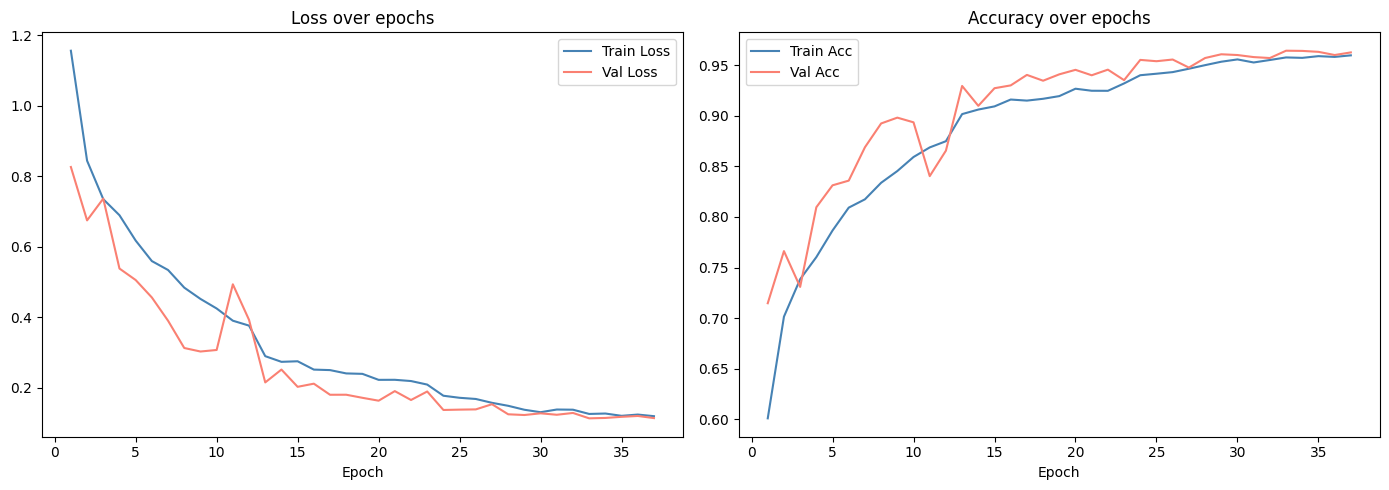

In [29]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
axes[0].plot(epochs, history["val_loss"], label="Val Loss", color="salmon")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="Train Acc", color="steelblue")
axes[1].plot(epochs, history["val_acc"], label="Val Acc", color="salmon")
axes[1].set_title("Accuracy over epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

The gradual decrease in loss as well as inrease in accuracy over the training process are clearly visible on the graph.

Next, the model will be evaluated on a test set.

In [30]:
model.load_state_dict(torch.load("best_model.pth"))
test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

100%|██████████| 85/85 [00:04<00:00, 20.67it/s]

Test Loss: 0.1146 | Test Accuracy: 0.9585


Similar validation and test performance suggests that the model generalizes well, with no clear evidence of overfitting.

                      precision    recall  f1-score   support

          AnnualCrop       0.94      0.94      0.94       300
              Forest       0.99      0.99      0.99       300
HerbaceousVegetation       0.96      0.93      0.94       300
             Highway       0.92      0.95      0.94       250
          Industrial       0.98      0.96      0.97       250
             Pasture       0.94      0.95      0.94       200
       PermanentCrop       0.93      0.93      0.93       250
         Residential       0.99      1.00      0.99       300
               River       0.94      0.94      0.94       250
             SeaLake       0.98      0.98      0.98       300

            accuracy                           0.96      2700
           macro avg       0.96      0.96      0.96      2700
        weighted avg       0.96      0.96      0.96      2700



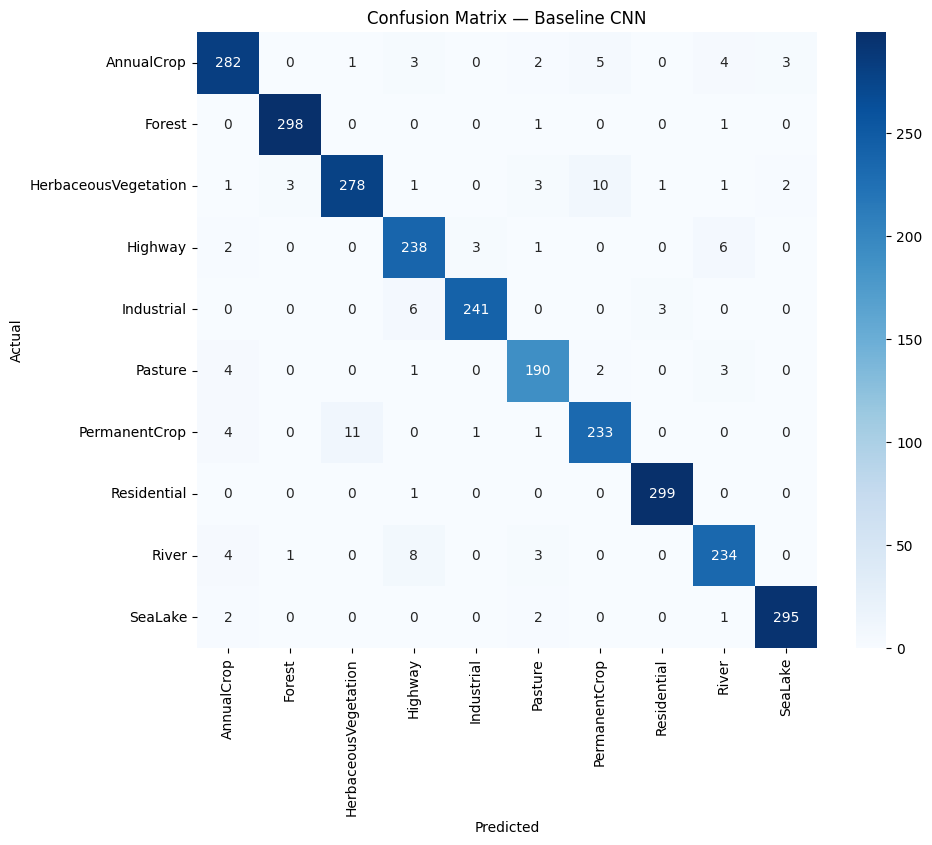

In [32]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

idx_to_class = {v: k for k, v in label_map.items()}
class_names = [idx_to_class[i] for i in range(10)]

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Baseline CNN")
plt.show()

The baseline demonstrated good performance on the EuroSAT classification task, achieving an overall accuracy of **96%** on the test set. The model also obtained macro and weighted F1-scores of **0.96**, indicating strong and well-balanced performance across all ten classes.

The classification report shows consistently high precision and recall values, with every class achieving an F1-score of at least **0.93**. The best-performing classes were Residential, Forest, and SeaLake, with F1-scores ranging from **0.98** to **0.99**. These classes contain distinctive visual characteristics that make them easier for the model to identify. The remaining classes, including AnnualCrop, Highway, Pasture, PermanentCrop, HerbaceousVegetation, and River, also achieved strong results, demonstrating that the model is capable of accurately recognizing a wide variety of land cover types.

The confusion matrix further confirms the model's effectiveness. Most misclassifications occur between classes with similar visual features. For example, PermanentCrop is occasionally confused with HerbaceousVegetation, River is sometimes classified as Highway, and Industrial is occasionally mistaken for Highway. These errors are understandable because these land cover categories often share similar textures, colors, and spatial patterns in satellite imagery, making them more difficult to distinguish.

Overall, the baseline CNN provides a strong foundation for land cover classification, achieving high accuracy with relatively few errors. Most remaining mistakes occur between similar classes, suggesting that further improvements, such as data augmentation, deeper network architectures (ResNet), transfer learning, or hyperparameter tuning, could further improve the model's ability to distinguish between these difficult categories.